# 03 · Embeddings and cosine similarity

So far a model gave us **text**. Now we ask a (different, much smaller) model
for **numbers**: an *embedding*, a fixed-length vector that encodes what a
piece of text means.

The promise is simple and slightly magical:

> sentences with similar meanings get vectors that point in similar directions.

That single property is what makes retrieval (notebook 05) and therefore
knowledge bases for agents (notebook 09) possible. So we are going to do the
arithmetic **by hand** before we let any library do it for us.

Plan:

1. get one embedding, look at it
2. derive cosine similarity from the dot product, implement it in numpy
3. test it on sentence pairs that are close vs. far in meaning
4. a full similarity matrix + heatmap
5. compare **three** embedding models, and see what is *not* comparable

In [ ]:
%pip install -q -r ../requirements.txt

In [2]:
import pathlib
import sys

ROOT = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "common").is_dir()
)
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from common.workshop_setup import embed_model_names, get_embeddings, timer

np.set_printoptions(precision=4, suppress=True)

## 1 · What an embedding actually looks like

We use Ollama's embedding models for this notebook. They are small (67 MB to
640 MB), they run in milliseconds on a CPU, and — unlike chat models — they
are *deterministic*: same text in, same vector out, every time.

In [3]:
embedder = get_embeddings("nomic-embed-text:latest")

with timer("one embedding"):
    vector = embedder.embed_query("The patient was prescribed antibiotics.")

vector = np.array(vector)
print("dimensions :", vector.shape[0])
print("first 8     :", vector[:8])
print("length |v|  :", np.linalg.norm(vector).round(4))
print("min / max   :", vector.min().round(3), "/", vector.max().round(3))

[one embedding: 1.07s]
dimensions : 768
first 8     : [ 0.0577  0.0422 -0.1552 -0.0549  0.0304  0.0021 -0.0865  0.0011]
length |v|  : 1.0
min / max   : -0.155 / 0.098


So: one sentence → 768 numbers. Individually they mean nothing (nobody knows
what dimension 412 "is"). Only **relations between vectors** are meaningful.

Note the length `|v|`. Some models return already-normalised vectors
(`|v| = 1`), some don't. We're about to build a measure that doesn't care.

## 2 · Cosine similarity, from scratch

For two vectors **a** and **b**, the dot product is

$$ \mathbf{a} \cdot \mathbf{b} \;=\; \sum_i a_i b_i \;=\; \|\mathbf{a}\|\,\|\mathbf{b}\|\cos\theta $$

Rearrange and you get the **cosine of the angle between them**:

$$ \cos\theta \;=\; \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \, \|\mathbf{b}\|} $$

Why the angle and not the plain distance? Because we want to compare
*direction* (meaning) and ignore *magnitude* (which correlates with things
like text length). Dividing by the norms does exactly that.

Range: `+1` same direction, `0` orthogonal/unrelated, `-1` opposite.
In practice, with real text embeddings, you rarely see anything below ~0.

Three lines:

In [4]:
def cosine_similarity(a, b) -> float:
    """cos(theta) between two vectors. Written out so you can see every step."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    dot = np.dot(a, b)                 # sum of elementwise products
    norm_a = np.sqrt(np.dot(a, a))     # = np.linalg.norm(a)
    norm_b = np.sqrt(np.dot(b, b))

    return float(dot / (norm_a * norm_b))


# Sanity checks on vectors we can reason about without a model:
print("identical   :", cosine_similarity([1, 0], [1, 0]))         # 1.0
print("orthogonal  :", cosine_similarity([1, 0], [0, 1]))         # 0.0
print("opposite    :", cosine_similarity([1, 0], [-1, 0]))        # -1.0
print("same dir, 5x:", cosine_similarity([1, 1], [5, 5]))         # 1.0 -- scale ignored
print("45 degrees  :", round(cosine_similarity([1, 0], [1, 1]), 4))  # 0.7071 = 1/sqrt(2)

identical   : 1.0
orthogonal  : 0.0
opposite    : -1.0
same dir, 5x: 0.9999999999999998
45 degrees  : 0.7071


### Aside: on normalised vectors, cosine *is* the dot product

If you divide every vector by its own length first (`v / |v|`), then
`|a| = |b| = 1` and the formula collapses to just `a · b`. That is why
production vector databases store normalised vectors: a similarity search
becomes one big matrix multiplication.

In [5]:
def normalise(matrix):
    """Scale each row to unit length."""
    matrix = np.asarray(matrix, dtype=float)
    return matrix / np.linalg.norm(matrix, axis=1, keepdims=True)


a, b = np.random.default_rng(0).normal(size=(2, 8))
print("cosine        :", round(cosine_similarity(a, b), 6))
print("dot of unit vs:", round(float(normalise([a])[0] @ normalise([b])[0]), 6))

cosine        : -0.248865
dot of unit vs: -0.248865


## 3 · Does it actually track meaning?

Now the real test. Pairs where we *know* the answer.

In [6]:
pairs = [
    # --- should be CLOSE: same meaning, different words -------------------
    ("The doctor prescribed antibiotics to the patient.",
     "The physician gave the patient a course of antibiotics.", "close"),
    ("The football team won the championship final.",
     "The soccer squad took the title in the last match.", "close"),
    ("Students submitted their dissertations before the deadline.",
     "The pupils handed in their theses on time.", "close"),

    # --- should be FAR: different topics entirely -------------------------
    ("The doctor prescribed antibiotics to the patient.",
     "The football team won the championship final.", "far"),
    ("Students submitted their dissertations before the deadline.",
     "Inflation pushed up the price of olive oil this quarter.", "far"),
    ("A neural network was trained for 40 epochs.",
     "She baked a lemon cake for her grandmother's birthday.", "far"),

    # --- the interesting middle ground ------------------------------------
    ("The doctor prescribed antibiotics to the patient.",
     "The nurse measured the patient's blood pressure.", "related topic"),
    ("The football team won the championship final.",
     "The football team lost the championship final.", "same topic, OPPOSITE meaning"),
]

# Embed every unique sentence once (embedding calls are the expensive part).
sentences = sorted({s for pair in pairs for s in pair[:2]})
with timer(f"embedding {len(sentences)} sentences"):
    vectors = embedder.embed_documents(sentences)
lookup = dict(zip(sentences, vectors))

rows = []
for left, right, expectation in pairs:
    rows.append(
        {
            "expected": expectation,
            "cosine": round(cosine_similarity(lookup[left], lookup[right]), 4),
            "A": left[:44] + "…",
            "B": right[:44] + "…",
        }
    )

results = pd.DataFrame(rows).sort_values("cosine", ascending=False)
print(results.to_string(index=False))

[embedding 11 sentences: 0.14s]
                    expected  cosine                                             A                                             B
                       close  0.9459 The doctor prescribed antibiotics to the pat… The physician gave the patient a course of a…
same topic, OPPOSITE meaning  0.8990 The football team won the championship final… The football team lost the championship fina…
                       close  0.7352 Students submitted their dissertations befor…   The pupils handed in their theses on time.…
                       close  0.7199 The football team won the championship final… The soccer squad took the title in the last …
               related topic  0.6403 The doctor prescribed antibiotics to the pat… The nurse measured the patient's blood press…
                         far  0.4433  A neural network was trained for 40 epochs.… She baked a lemon cake for her grandmother's…
                         far  0.3995 The doctor prescribed antibi

### Read that table carefully, two lessons hide in it

**1. It works.** The paraphrase pairs score far above the unrelated pairs,
even though they share almost no words. That is the difference between
embeddings and keyword search: *"physician"* and *"doctor"* have no letters in
common, and the model still knows.

**2. It does not understand negation.** Look at the last pair: *"won the
final"* vs *"lost the final"* scores **very high**. Cosine similarity measures
*"is this about the same thing?"*, not *"does this say the same thing?"*.

That limitation matters for us practically: a retrieval system will happily
hand an agent a document that says the exact opposite of what was asked. Which
is one good reason why, in notebook 10, we give our multi-agent system a
**critic** that reads the retrieved evidence instead of trusting the scores.

## 4 · The similarity matrix

Comparing pairs is fine. Comparing *everything to everything* is a matrix
multiplication — and it draws nicely.

In [7]:
corpus = [
    "The doctor prescribed antibiotics.",          # health
    "The nurse checked the patient's chart.",      # health
    "MRI scans revealed no abnormality.",          # health
    "The striker scored in the 90th minute.",      # sport
    "Our team lost the final on penalties.",       # sport
    "He trains for the marathon every morning.",   # sport
    "The lecture on linear algebra was packed.",   # education
    "Students must submit the essay by Friday.",   # education
    "The university introduced a new curriculum.", # education
]

matrix = normalise(embedder.embed_documents(corpus))

# Every pairwise cosine in one line, because the rows are unit length.
similarity = matrix @ matrix.T
print("similarity matrix shape:", similarity.shape)

similarity matrix shape: (9, 9)


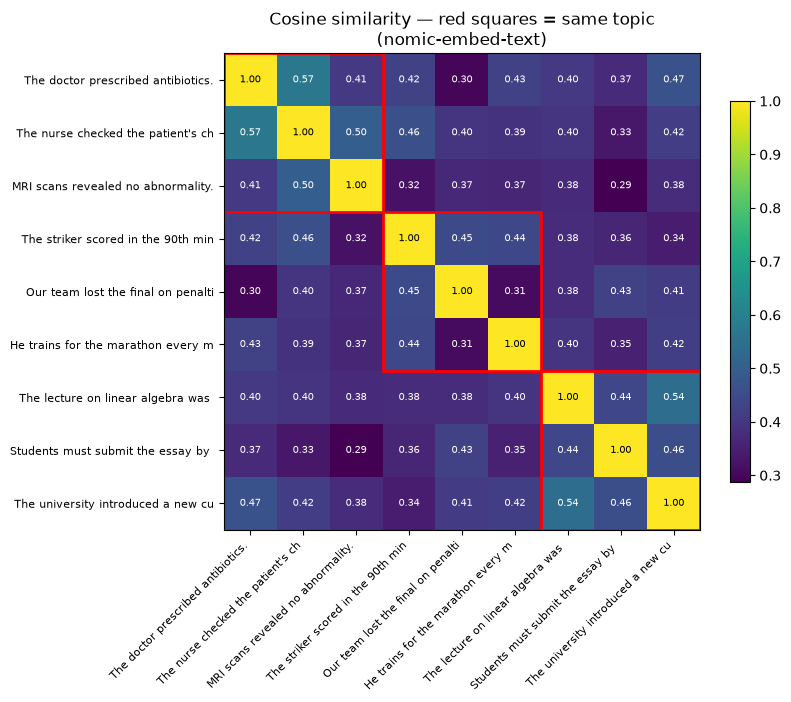

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 7))
image = ax.imshow(similarity, cmap="viridis", vmin=similarity.min(), vmax=1.0)

short = [s[:34] for s in corpus]
ax.set_xticks(range(len(corpus)), short, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corpus)), short, fontsize=8)

for i in range(len(corpus)):
    for j in range(len(corpus)):
        ax.text(
            j, i, f"{similarity[i, j]:.2f}",
            ha="center", va="center", fontsize=7,
            color="white" if similarity[i, j] < 0.75 else "black",
        )

# Mark the 3x3 topic blocks we expect to light up.
for start in (0, 3, 6):
    ax.add_patch(plt.Rectangle((start - 0.5, start - 0.5), 3, 3,
                               fill=False, edgecolor="red", linewidth=2))

ax.set_title("Cosine similarity — red squares = same topic\n(nomic-embed-text)")
fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

The diagonal is 1.0 (everything is identical to itself). The three red blocks
should be visibly brighter than everything outside them. **That block
structure is the entire basis of semantic search** — and in notebook 04 we
will look at the same structure again, geometrically, in 2D.

## 5 · Nearest-neighbour search, i.e. "retrieval" in 5 lines

Retrieval is nothing but: embed the query, cosine it against everything,
take the top *k*. Notebook 05 adds chunking and a prompt around this — but
the core is here.

In [9]:
def search(query: str, k: int = 3):
    query_vector = normalise([embedder.embed_query(query)])[0]
    scores = matrix @ query_vector                # one cosine per document
    best = np.argsort(-scores)[:k]                # highest first
    return [(round(float(scores[i]), 4), corpus[i]) for i in best]


for query in ["Something about hospitals", "Who won the match?", "exam deadlines"]:
    print(f"\nQ: {query}")
    for score, document in search(query):
        print(f"   {score}  {document}")


Q: Something about hospitals
   0.5503  The nurse checked the patient's chart.
   0.4905  The doctor prescribed antibiotics.
   0.4275  The university introduced a new curriculum.

Q: Who won the match?
   0.5602  Our team lost the final on penalties.
   0.5566  The striker scored in the 90th minute.
   0.5086  The nurse checked the patient's chart.

Q: exam deadlines
   0.6022  Students must submit the essay by Friday.
   0.4859  The university introduced a new curriculum.
   0.45  The lecture on linear algebra was packed.


## 6 · Comparing three embedding models

There is no single "the" embedding. Models differ in dimension, in speed, in
training data, and in what they consider similar. Let's measure ours:

| model | size | note |
|-------|------|------|
| `nomic-embed-text:latest` | 274 MB | long context, retrieval-oriented |
| `qwen3-embedding:0.6b` | 640 MB | newest, multilingual, biggest vectors |
| `all-minilm:33m` | 67 MB | tiny classic baseline — 30× smaller |

In [10]:
model_names = embed_model_names()
print("comparing:", model_names)

probe_pairs = [
    ("paraphrase",
     "The physician prescribed antibiotics.",
     "The doctor gave medication to the patient."),
    ("same topic",
     "The physician prescribed antibiotics.",
     "The nurse recorded the patient's temperature."),
    ("unrelated",
     "The physician prescribed antibiotics.",
     "The striker scored in the 90th minute."),
    ("negation",
     "Our team won the final.",
     "Our team lost the final."),
    ("cross-language",
     "The cat sleeps on the sofa.",
     "Die Katze schläft auf dem Sofa."),
]

report = []
for name in model_names:
    try:
        model = get_embeddings(name)
        texts = sorted({t for _, a, b in probe_pairs for t in (a, b)})

        with timer(f"{name}: {len(texts)} texts") as clock:
            vecs = dict(zip(texts, model.embed_documents(texts)))

        row = {
            "model": name,
            "dim": len(next(iter(vecs.values()))),
            "sec": round(clock.seconds, 2),
        }
        for label, a, b in probe_pairs:
            row[label] = round(cosine_similarity(vecs[a], vecs[b]), 3)
        report.append(row)
    except Exception as exc:
        print(f"❌ {name}: {type(exc).__name__} — did you `ollama pull {name}`?")

comparison = pd.DataFrame(report).set_index("model")
print()
print(comparison.to_string())

comparing: ['nomic-embed-text:latest', 'qwen3-embedding:0.6b', 'all-minilm:33m']
[nomic-embed-text:latest: 8 texts: 0.10s]
[qwen3-embedding:0.6b: 8 texts: 10.84s]
[all-minilm:33m: 8 texts: 0.66s]

                          dim    sec  paraphrase  same topic  unrelated  negation  cross-language
model                                                                                            
nomic-embed-text:latest   768   0.10       0.808       0.533      0.433     0.880           0.654
qwen3-embedding:0.6b     1024  10.84       0.815       0.581      0.325     0.837           0.822
all-minilm:33m            384   0.66       0.786       0.356      0.096     0.873           0.259


### How to read this table (this is the important cell)

**Do not compare numbers across rows.** A `0.82` from one model and a `0.82`
from another mean nothing to each other — each model has its own
"temperature" for similarity. `all-minilm` tends to spread scores widely;
`qwen3-embedding` squeezes almost everything into a narrow high band.

What *is* comparable, and what you should actually check:

1. **Ordering.** Within a row, is `paraphrase > same topic > unrelated`? That
   ranking is what a retriever depends on. All three models should get it right.
2. **Separation.** How big is the gap between `paraphrase` and `unrelated`?
   A bigger gap makes your top-*k* cut-offs easier to tune.
3. **Multilingual ability.** Look at `cross-language`. The English/German pair
   is the *same sentence*. Models trained multilingually score it high; the
   English-only baseline does not. If your corpus isn't English, this column
   decides your model.
4. **Cost.** `dim` sets your storage and search cost; `sec` sets your indexing
   cost. `all-minilm` is ~4× smaller *and* faster than nomic. If it ranks
   correctly on *your* data, the cheap model is the right model.

**Practical consequence:** never pick an embedding model from a leaderboard.
Build a table like this one with fifteen pairs from your own domain, it takes
ten minutes and it is worth more than any benchmark.

In [11]:
# The separation gap, made explicit -- a crude but useful "is this model
# discriminating?" score.
if not comparison.empty:
    gap = (comparison["paraphrase"] - comparison["unrelated"]).sort_values(ascending=False)
    print("separation (paraphrase − unrelated), higher is better:\n")
    print(gap.to_string())

separation (paraphrase − unrelated), higher is better:

model
all-minilm:33m             0.690
qwen3-embedding:0.6b       0.490
nomic-embed-text:latest    0.375


## One gotcha you will hit in the wild: task prefixes

Some embedding models are trained *asymmetrically*: queries and documents get
different prefixes, e.g. nomic expects `search_query: …` and
`search_document: …`. Skipping them costs a few points of retrieval quality.

LangChain's `OllamaEmbeddings` gives you `embed_query` and `embed_documents`
as separate methods exactly so a wrapper *can* apply that distinction. Always
read your embedding model's model card before you index a million documents.

In [12]:
query_style = embedder.embed_query("antibiotics")
document_style = embedder.embed_documents(["antibiotics"])[0]
print("query vs document embedding of the same word:",
      round(cosine_similarity(query_style, document_style), 4))

query vs document embedding of the same word: 1.0


## Your turn 10 minutes

1. Add three sentence pairs **from your own field** to `probe_pairs` and
   re-run the comparison. Does the ranking still hold? Does your favourite
   model change?
2. Find a pair of sentences that *should* be far apart but scores high.
   (Hint: negation, numbers, named entities, dates.) These are the failure
   modes your RAG system will inherit.
3. Replace `cosine_similarity` with plain Euclidean distance
   (`np.linalg.norm(a - b)`). Does the ranking of the pairs change? Now
   re-run it on **normalised** vectors and explain why the two agree there.

→ Next: **04 · Mapping meaning with PCA and UMAP**, we generate a few dozen
documents with an LLM and *look* at the structure we just measured.